In [2]:
import pandas as pd

df = pd.read_csv(
    "/Users/hwayoungshin/Desktop/LeafIoT/hf426-01-rsip.csv",
    encoding="latin1"
)

df.head()

,ID,Reference,Species,Synonym,Family,Growth_form,Life_span,Tissue,Seed_Cat,Leaf_strategy,...,MAE,Ai,Sa,Msur,Mdef,Psur,Pdef,Rclass,Rregime,Aclass
0,1,Abbott et al. 1991,Agropyron cristatum,NaN,Poaceae,Grass,P,Herbaceous,Monocot,NaN,...,1.042,0.21,0.029,3.0,8.0,0.029,0.768,B,E,sa
1,2,Abbott et al. 1991,Artemisia tridentata ssp. wyomingensis,NaN,Asteraceae,Semi-shrub,P,Woody,Dicot,E,...,1.042,0.21,0.029,3.0,8.0,0.029,0.768,B,E,sa
2,3,Abbott et al. 1991,Chrysothamnus viscidiflorus,NaN,Asteraceae,Shrub,P,Woody,Dicot,D,...,1.042,0.21,0.029,3.0,8.0,0.029,0.768,B,E,sa
3,4,Abbott et al. 1991,Elymus elymoides,NaN,Poaceae,Grass,P,Herbaceous,Monocot,NaN,...,1.042,0.21,0.029,3.0,8.0,0.029,0.768,B,E,sa
4,5,Abbott et al. 1991,Elymus lanceolatus,NaN,Poaceae,Grass,P,Herbaceous,Monocot,NaN,...,1.042,0.21,0.029,3.0,8.0,0.029,0.768,B,E,sa


In [3]:
df.shape

(5654, 70)

In [4]:
df.columns.tolist()

['ID',
 'Reference',
 'Species',
 'Synonym',
 'Family',
 'Growth_form',
 'Life_span',
 'Tissue',
 'Seed_Cat',
 'Leaf_strategy',
 'Leaf_form',
 'PS_type',
 'Dr',
 'Lr',
 'Wr',
 'Dl',
 'Hs',
 'Ws',
 'DBH',
 'Vr',
 'Vs',
 'Drel',
 'Lrel',
 'Y_Xshoot',
 'Y_Xroot',
 'S_Ry',
 'S_Rx',
 'Biome',
 'Eco_Name',
 'Realm',
 'Eco_ID',
 'Vegetation',
 'Location',
 'Lat',
 'Long',
 'Spatial_buffer',
 'Elevation',
 'Soil_description',
 'USDA_soil_texture',
 'EU_soil_texture',
 'Water_Table_Depth_Fan',
 'BIO1',
 'BIO2',
 'BIO3',
 'BIO4',
 'BIO5',
 'BIO6',
 'BIO7',
 'BIO8',
 'BIO9',
 'BIO10',
 'BIO11',
 'BIO13',
 'BIO14',
 'BIO15',
 'BIO16',
 'BIO17',
 'BIO18',
 'BIO19',
 'MAP',
 'MAE',
 'Ai',
 'Sa',
 'Msur',
 'Mdef',
 'Psur',
 'Pdef',
 'Rclass',
 'Rregime',
 'Aclass']

In [5]:
df['Growth_form'].value_counts()

Growth_form
Forb          1716
Tree          1576
Grass          991
Shrub          693
Semi-shrub     574
Succulent       87
succulent        2
shrub            1
Name: count, dtype: int64

In [6]:
trees = df[df['Growth_form'].str.contains('tree', case=False, na=False)]

trees.shape

(1576, 70)

In [7]:
trees[['Dr','Lr','Hs','Ws','DBH']].isnull().sum()

Dr        4
Lr     1192
Hs     1161
Ws     1326
DBH    1444
dtype: int64

In [8]:
trees['Dr'].describe()

count    1572.000000
mean        3.641872
std         7.694856
min         0.070000
25%         1.000000
50%         1.750000
75%         3.100000
max       120.000000
Name: Dr, dtype: float64

In [9]:
trees['Lr'].describe()

count    384.000000
mean       7.043338
std        6.999237
min        0.006700
25%        2.372500
50%        5.150000
75%        8.757500
max       50.000000
Name: Lr, dtype: float64

In [10]:
trees[['Dr','Lr','Hs','Ws','DBH']].corr(numeric_only=True)

,Dr,Lr,Hs,Ws,DBH
Dr,1.000000,0.154236,0.212474,0.194606,0.200443
Lr,0.154236,1.000000,0.591586,0.726136,0.512021
Hs,0.212474,0.591586,1.000000,0.791695,0.881380
Ws,0.194606,0.726136,0.791695,1.000000,0.852989
DBH,0.200443,0.512021,0.881380,0.852989,1.000000


In [11]:
trees[['Dr','Drel','Lr','Lrel']].head()

,Dr,Drel,Lr,Lrel
6,1.20,NaN,8.0,NaN
7,1.30,NaN,7.0,NaN
28,4.50,NaN,NaN,NaN
72,1.52,NaN,NaN,NaN
97,2.10,0.000475,13.6,0.003074


In [12]:
trees[['Dr',
       'Elevation',
       'Lat',
       'Long']].corr(numeric_only=True)

,Dr,Elevation,Lat,Long
Dr,1.000000,0.136163,-0.228476,0.032749
Elevation,0.136163,1.000000,-0.105247,0.031367
Lat,-0.228476,-0.105247,1.000000,-0.317546
Long,0.032749,0.031367,-0.317546,1.000000


In [13]:
trees['USDA_soil_texture'].value_counts().head(20)

USDA_soil_texture
Sa        334
SaLo      238
LoSa      167
Lo        139
SiLo      112
Cl        104
SaCl       89
Ro         70
SaClLo     50
ClLo       48
SiClLo     39
Wa         34
Si         32
SiCl       13
Name: count, dtype: int64

In [14]:
trees.groupby('USDA_soil_texture')['Dr'].median().sort_values()

USDA_soil_texture
Wa        0.490
ClLo      1.050
SiCl      1.100
Cl        1.500
SaLo      1.520
Lo        1.590
SiClLo    1.690
SaClLo    1.725
Sa        1.775
SiLo      1.800
LoSa      1.805
SaCl      2.000
Si        2.200
Ro        5.000
Name: Dr, dtype: float64

In [15]:
trees['Dr'].describe()

count    1572.000000
mean        3.641872
std         7.694856
min         0.070000
25%         1.000000
50%         1.750000
75%         3.100000
max       120.000000
Name: Dr, dtype: float64

In [16]:
trees['Dr'].sort_values(ascending=False).head(20)

959     120.0
4207     78.6
4580     70.0
4579     70.0
1074     68.0
535      61.0
1073     60.0
4582     60.0
469      60.0
1629     58.0
4576     55.0
4611     53.0
4581     47.0
1435     45.0
4578     40.0
4577     40.0
667      40.0
1431     40.0
4583     40.0
496      36.5
Name: Dr, dtype: float64

In [17]:
trees.nlargest(20,'Dr')[[
    'Species',
    'Family',
    'Dr',
    'USDA_soil_texture',
    'Elevation',
    'Lat',
    'Long'
]]

,Species,Family,Dr,USDA_soil_texture,Elevation,Lat,Long
959,Ficus sp.,Moraceae,120.0,NaN,NaN,-24.7500,30.5700
4207,Boscia albitrunca,Capparaceae,78.6,Sa,1031.0,-25.2608,23.3172
4579,Acacia erioloba,Fabaceae,70.0,LoSa,1221.0,-22.3134,26.4283
4580,Boscia albitrunca,Capparaceae,70.0,LoSa,1221.0,-22.3134,26.4283
1074,Boscia albitrunca,Capparaceae,68.0,Sa,1118.0,-23.9500,22.9712
535,Juniperus monosperma,Cupressaceae,61.0,SaCl,6000.0,35.1700,-107.9000
469,Prosopis cineraria,Mimosaceae,60.0,Sa,279.0,22.0000,59.0000
1073,Acacia erioloba,Fabaceae,60.0,Sa,NaN,-24.0000,23.0000
4582,Securidaca longipedunculata,Polygalaceae,60.0,LoSa,1228.0,-22.2770,26.4759
1629,Prosopis velutina,Fabaceae,58.0,Sa,NaN,32.4000,-111.1400


In [18]:
soil_stats = (
    trees.groupby('USDA_soil_texture')
    .agg(
        n=('Dr','count'),
        median_Dr=('Dr','median'),
        mean_Dr=('Dr','mean'),
        std_Dr=('Dr','std')
    )
    .sort_values('median_Dr')
)

soil_stats

,n,median_Dr,mean_Dr,std_Dr
USDA_soil_texture,,,,
Wa,34,0.490,1.340588,2.834062
ClLo,48,1.050,2.137685,3.294638
SiCl,13,1.100,1.750846,1.349191
Cl,103,1.500,2.274569,2.586517
SaLo,238,1.520,2.111619,2.019327
Lo,139,1.590,2.090745,2.232522
SiClLo,39,1.690,1.900513,1.253324
SaClLo,50,1.725,4.188000,6.815980
Sa,334,1.775,4.163184,9.190276


In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13],
 [Text(0, 0, 'Wa'),
  Text(1, 0, 'ClLo'),
  Text(2, 0, 'SiCl'),
  Text(3, 0, 'Cl'),
  Text(4, 0, 'SaLo'),
  Text(5, 0, 'Lo'),
  Text(6, 0, 'SiClLo'),
  Text(7, 0, 'SaClLo'),
  Text(8, 0, 'Sa'),
  Text(9, 0, 'SiLo'),
  Text(10, 0, 'LoSa'),
  Text(11, 0, 'SaCl'),
  Text(12, 0, 'Si'),
  Text(13, 0, 'Ro')])

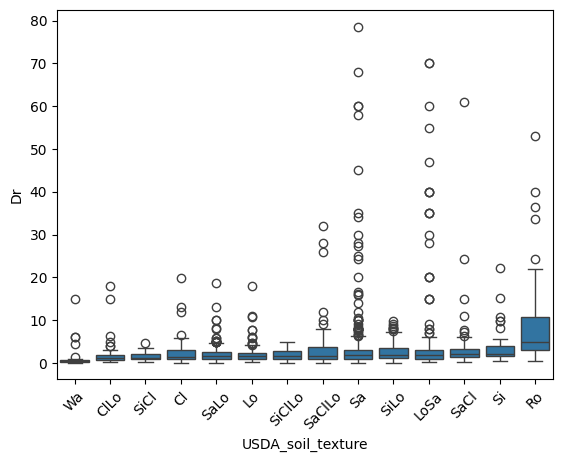

In [20]:
sns.boxplot(
    data=trees,
    x='USDA_soil_texture',
    y='Dr',
    order=soil_stats.index
)

plt.xticks(rotation=45)

In [21]:
trees.loc[
    trees['Dr']==120,
    ['Reference','Species','Dr']
]

,Reference,Species,Dr
959,Guinness 2003,Ficus sp.,120.0


In [22]:
trees_no120 = trees[trees['Dr'] < 120]

trees['Dr'].describe()

trees_no120['Dr'].describe()

count    1571.000000
mean        3.567805
std         7.114727
min         0.070000
25%         1.000000
50%         1.750000
75%         3.100000
max        78.600000
Name: Dr, dtype: float64

<Axes: xlabel='Dr'>

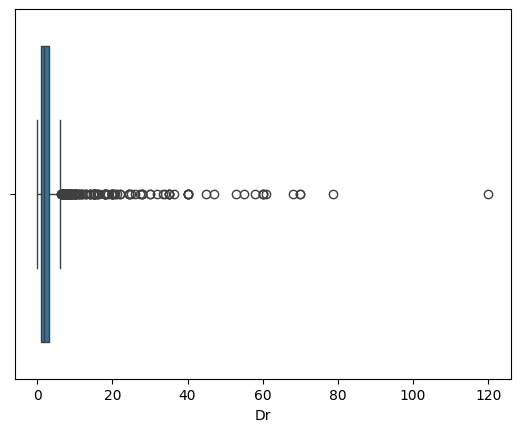

In [23]:
sns.boxplot(x=trees['Dr'])

<Axes: xlabel='Dr'>

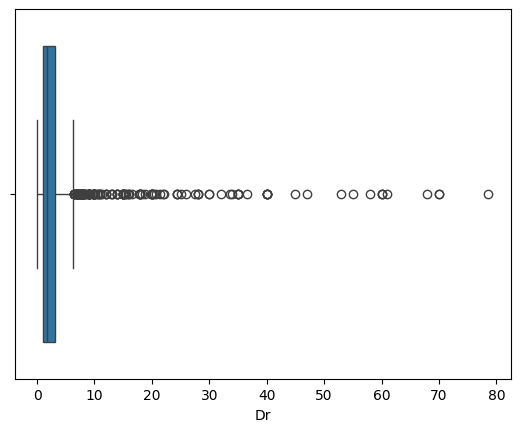

In [24]:
sns.boxplot(x=trees_no120['Dr'])

In [25]:
trees['Species'].value_counts().head(30)

Species
Picea mariana               31
Picea glauca                30
Pinus resinosa              24
Pinus sylvestris            24
Quercus robur               24
Picea abies                 23
Abies balsamea              21
Pinus sp.                   20
Pseudotsuga menziesii       18
Acer saccharum              17
Fagus sylvatica             17
Pinus contorta              15
Brachystegia spiciformis    14
Castanea sativa             14
Pinus banksiana             12
Populus tremuloides         12
Carpinus betulus            11
Prosopis glandulosa         11
Terminalia sericea          11
Pinus pinaster              11
Larix decidua               10
Pinus taeda                 10
Pinus radiata               10
Pinus cembra                 9
Brachystegia boehmii         9
Pinus edulis                 9
Quercus fusiformis           9
Erythrophleum africanum      9
Ulmus americana              8
Faidherbia albida            8
Name: count, dtype: int64

In [26]:
ratio_df = pd.read_csv("pure_trees.csv")

FileNotFoundError: [Errno 2] No such file or directory: 'pure_trees.csv'

In [ ]:
df["Species"].nunique()

In [27]:
df["Biome"].value_counts(normalize=True) * 100

Biome
Deserts & Xeric Shrublands                                  22.107328
Temperate Conifer Forests                                   19.807452
Temperate Grasslands; Savannas & Shrublands                 18.202888
Temperate Broadleaf & Mixed Forests                         11.570690
Mediterranean Forests; Woodlands & Scrub                     6.756998
Tropical & Subtropical Grasslands; Savannas & Shrublands     5.348547
Tropical & Subtropical Dry Broadleaf Forests                 4.403637
Montane Grasslands & Shrublands                              3.957925
Boreal Forests/Taiga                                         3.333928
Tropical & Subtropical Moist Broadleaf Forests               2.567303
Flooded Grasslands & Savannas                                1.158852
Tundra                                                       0.445712
Mediterranean Forests; Woodlands & Scrubs                    0.267427
Tropical & Subtropical Coniferous Forests                    0.053485
Tropical & sub